# Title

Motivated by a game developed by [Sebastian Lague](https://youtu.be/sLqXFF8mlEU?si=fPeEBiPfLtePQZq5), in this notebook I show different ways to map a plane world map into a sphere. In the end, I discuss some mathematics about the imposibility to map the sphere to a plane faithfully.

Two approaches to wrap a map arise inmediatly: (1) start with a mesh of a rectangle, and wrap the rectangle onto a sphere, and (2) mesh a sphere, unwrap it into a rectangle. We will see that, although mathematically equivalent, both approaches exhibit its pros and cons.

In [1]:
import pyvista as pv
from PIL import Image
import numpy as np

pv.set_jupyter_backend('trame')

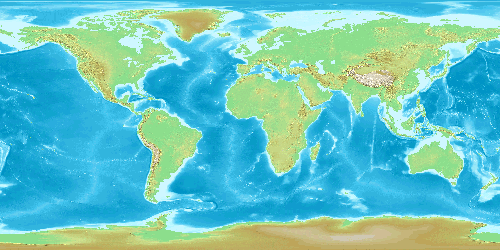

In [2]:
im = Image.open('Maps/WorldMap-A_non-Frame.png')
thumbnail = im.copy()
thumbnail.thumbnail((500, 1200))
thumbnail

In [3]:
data = np.array(im)
data.shape, data.min(), data.max()

((3980, 7964), 0, 255)

# 1. From the Plane to the Sphere

## Uniformly Sampled Polar Angles

The simplest way to "wrap" a rectangle in a sphere if one is by using polar coordinates. Although simple, meshing the rectangle without much care my produce a biased mesh (large disparity in the concentration of points). For example, sampling the angles uniformly yields a concentration of points in the poles (see the cell `Sphere mesh 1.` below) and sparsity in the equator.

In [4]:
#  Sphere mesh 1.


# Resolution of the mesh
num_lat_points = 500
num_lon_points = 1200


# Polar angles
phi = np.linspace(0, np.pi, endpoint=False, num=num_lat_points)
theta = np.linspace(0, 2*np.pi, endpoint=False, num=num_lon_points)

THETA, PHI = np.meshgrid(theta, phi, indexing='xy')

plane_coordinates = np.dstack([THETA, PHI, np.ones_like(THETA)]).reshape(-1, 3)

S_THETA = np.sin(THETA)
S_PHI = np.sin(PHI)
C_THETA = np.cos(THETA)
C_PHI = np.cos(PHI)

# Mapping to the sphere
X, Y, Z = S_PHI*C_THETA, S_PHI*S_THETA, C_PHI

sphere_vertices = np.dstack([X, Y, Z]).reshape(-1, 3)

pv_sphere = pv.PolyData(sphere_vertices)
pv_sphere.plot(point_size=5)

Widget(value='<iframe src="http://localhost:37997/index.html?ui=P_0x7f677a7c78c0_0&reconnect=auto" class="pyvi…

### Plane to Sphere

In `Sphere mesh 1.` we built a function $G\colon [0, \pi)\times [0, 2\pi) \to \mathbb S^2$ from the rectangle to the sphere. Hence, it is natural to first massage the image to the rectangle and then use $G$ to send it onto the sphere.

In [5]:
def triangulate_rectangle_grid(height, width):
    triangles = []
    for i in range(width * (height-1)):
        #  i = nrow * width + ncol
        ncol = i % width
        nrow = (i - ncol) // width
    
        if nrow < height-1:
            if ncol < width-1:
                triangles.append([3, i, i+1, i+width])
    
            if ncol > 0:
                triangles.append([3, i+width-1, i, i+width])
    return triangles

In [6]:
h, w = data.shape[:2]

PHI_IMAGE_SPACE = h * PHI/np.pi
THETA_IMAGE_SPACE = w * THETA/(2*np.pi)

coords_img_space = np.stack([PHI_IMAGE_SPACE, THETA_IMAGE_SPACE]).reshape(2, -1)
colors = data[coords_img_space[0].astype(int), coords_img_space[1].astype(int)]

triangles = triangulate_rectangle_grid(num_lat_points, num_lon_points)
print('# triangles:', len(triangles))

# triangles: 1196602


In [7]:
pl = pv.Plotter()

pv_plane = pv.PolyData(plane_coordinates, triangles)
pv_plane['scalars'] = colors

pv_plane_actor = pl.add_mesh(pv_plane)
pv_plane_actor.position = np.array([0, 0, 0])

pl.show(interactive_update=True, auto_close=False)

Widget(value='<iframe src="http://localhost:37997/index.html?ui=P_0x7f6754f06ad0_1&reconnect=auto" class="pyvi…

In [8]:
# Animation
def make_movie(filename, pl=pl):
    pl.open_movie(filename, framerate=60)
    
    camera_position = np.array(pl.camera.position)
    for t in np.linspace(0, 1, num=60*4):
        pv_plane.points = t*sphere_vertices + (1-t)*plane_coordinates
        pl.camera.focal_point = pv_plane.center
        if t <= 0.5:
            pl.camera.position = (1-t)*camera_position + t*np.array(pl.camera.focal_point)
        pl.write_frame()
    
    for _ in range(60):
        pl.write_frame()
    pl.close()

make_movie('plane_to_sphere_meshed.mp4')

<video controls src='plane_to_sphere_meshed.mp4' width='600'></video>

## Non-uniformly Sampled Polar Angles

A way to fix the biased mesh is to sample each line (height) uniformly, but the decrease the number of points used when approaching the top and bottom. The question then is, if $N$ points are used in the equator, how many are required near the pole?

## Divide and Conquer: Filling by Patches

# 2. From the Sphere to the Plane